process the R_overall_matrix.csv to R_overall_ratio_matrix.csv

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  

output_path = "dataset\\out_R\\R_overall_ratio_matrix.csv"
input_path = "dataset\\out_R\\R_overall_matrix.csv" 
overall_matrix = pd.read_csv(input_path, index_col=0)

# 2. Divide the entire matrix by 46 to obtain ratios
ratio_matrix_df = overall_matrix / 46

ratio_matrix_df.head()

# 3. Save the result to a new path
ratio_matrix_df.to_csv(output_path)

print("saved to:", output_path)

saved to: dataset\out_R\R_overall_ratio_matrix.csv


d:\softwall_install\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
path = "dataset\\out_R\\R_overall_ratio_matrix.csv" 
sorted_df = pd.read_csv(path, index_col=0)
sorted_df

,California,Texas,Germany,Turkey,Egypt,Vietnam,Nigeria,India,Saudi
California,0.000000,0.434783,0.456522,0.413043,0.456522,0.521739,0.478261,0.543478,0.565217
Texas,0.434783,0.000000,0.326087,0.239130,0.239130,0.304348,0.260870,0.282609,0.304348
Germany,0.456522,0.326087,0.000000,0.304348,0.260870,0.326087,0.239130,0.304348,0.413043
Turkey,0.413043,0.239130,0.304348,0.000000,0.130435,0.239130,0.282609,0.260870,0.239130
Egypt,0.456522,0.239130,0.260870,0.130435,0.000000,0.108696,0.326087,0.173913,0.326087
Vietnam,0.521739,0.304348,0.326087,0.239130,0.108696,0.000000,0.347826,0.152174,0.391304
Nigeria,0.478261,0.260870,0.239130,0.282609,0.326087,0.347826,0.000000,0.326087,0.347826
India,0.543478,0.282609,0.304348,0.260870,0.173913,0.152174,0.326087,0.000000,0.413043
Saudi,0.565217,0.304348,0.413043,0.239130,0.326087,0.391304,0.347826,0.413043,0.000000


Visualization the overall_matrix: dataset\out_R\R_overall_matrix.csv

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  

In [4]:
output_path = "dataset\\out_R"
path = "dataset\\out_R\\R_overall_ratio_matrix.csv" 
overall_matrix = pd.read_csv(path, index_col=0)
overall_matrix.head()

,California,Texas,Germany,Turkey,Egypt,Vietnam,Nigeria,India,Saudi
California,0.000000,0.434783,0.456522,0.413043,0.456522,0.521739,0.478261,0.543478,0.565217
Texas,0.434783,0.000000,0.326087,0.239130,0.239130,0.304348,0.260870,0.282609,0.304348
Germany,0.456522,0.326087,0.000000,0.304348,0.260870,0.326087,0.239130,0.304348,0.413043
Turkey,0.413043,0.239130,0.304348,0.000000,0.130435,0.239130,0.282609,0.260870,0.239130
Egypt,0.456522,0.239130,0.260870,0.130435,0.000000,0.108696,0.326087,0.173913,0.326087


In [5]:


def plot_overall_diff_matrix(
    overall_matrix,
    # title="Pairwise Regional Regulation Difference",
    figsize=(10, 8),
    cmap="YlOrRd",
    annot=True,
    annot_fontsize=10,
    annot_color="black",
    tick_fontsize=11,
    title_fontsize=15,
    label_fontsize=12,
    colorbar_fontsize=11,
    rotation_x=45,
    rotation_y=0,
    vmin=None,
    vmax=None,
    save_path=None,
    dpi=300
):
    """
    Visualize overall_matrix as a confusion-matrix-like heatmap.

    Parameters
    ----------
    overall_matrix : pd.DataFrame
        Square matrix. Rows and columns are region names.
    title : str
        Plot title.
    figsize : tuple
        Figure size.
    cmap : str
        Matplotlib colormap, e.g., "YlOrRd", "Reds", "Blues", "viridis".
    annot : bool
        Whether to show numbers in cells.
    annot_fontsize : int
        Font size of cell numbers.
    annot_color : str
        Color of cell numbers.
    tick_fontsize : int
        Font size of region labels.
    title_fontsize : int
        Font size of title.
    label_fontsize : int
        Font size of x/y labels.
    colorbar_fontsize : int
        Font size of colorbar labels.
    rotation_x : int
        Rotation angle of x-axis labels.
    rotation_y : int
        Rotation angle of y-axis labels.
    vmin, vmax : int or float
        Color scale range. If None, use matrix min/max.
    save_path : str or None
        If provided, save figure to this path.
    dpi : int
        Resolution for saved figure.
    """

    regions = overall_matrix.index.tolist()
    data = overall_matrix.values

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # Axis ticks
    ax.set_xticks(np.arange(len(regions)))
    ax.set_yticks(np.arange(len(regions)))

    ax.set_xticklabels(
        regions,
        fontsize=tick_fontsize,
        rotation=rotation_x,
        ha="right"
    )
    ax.set_yticklabels(
        regions,
        fontsize=tick_fontsize,
        rotation=rotation_y
    )

    # Axis labels and title
    # ax.set_xlabel("Region", fontsize=label_fontsize)
    # ax.set_ylabel("Region", fontsize=label_fontsize)
    # ax.set_title(title, fontsize=title_fontsize, pad=15)

    # Add numbers inside cells
    if annot:
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                if data[i, j] != 0:
                    # First format to two decimal places (e.g., "0.08" or "1.25")
                    val_str = f"{data[i, j]:.4f}"
                    
                    # If it starts with "0.", remove the leading "0" to get ".08"
                    if val_str.startswith("0."):
                        val_str = val_str[1:]
                    # If it starts with "-0.", change it to "-.08"
                    elif val_str.startswith("-0."):
                        val_str = "-" + val_str[2:]
                    ax.text(
                        j,
                        i,
                        val_str,
                        ha="center",
                        va="center",
                        fontsize=annot_fontsize,
                        color=annot_color
                    )

    # Grid lines, similar to confusion matrix
    ax.set_xticks(np.arange(data.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Difference Ratio", fontsize=colorbar_fontsize)
    cbar.ax.tick_params(labelsize=colorbar_fontsize)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

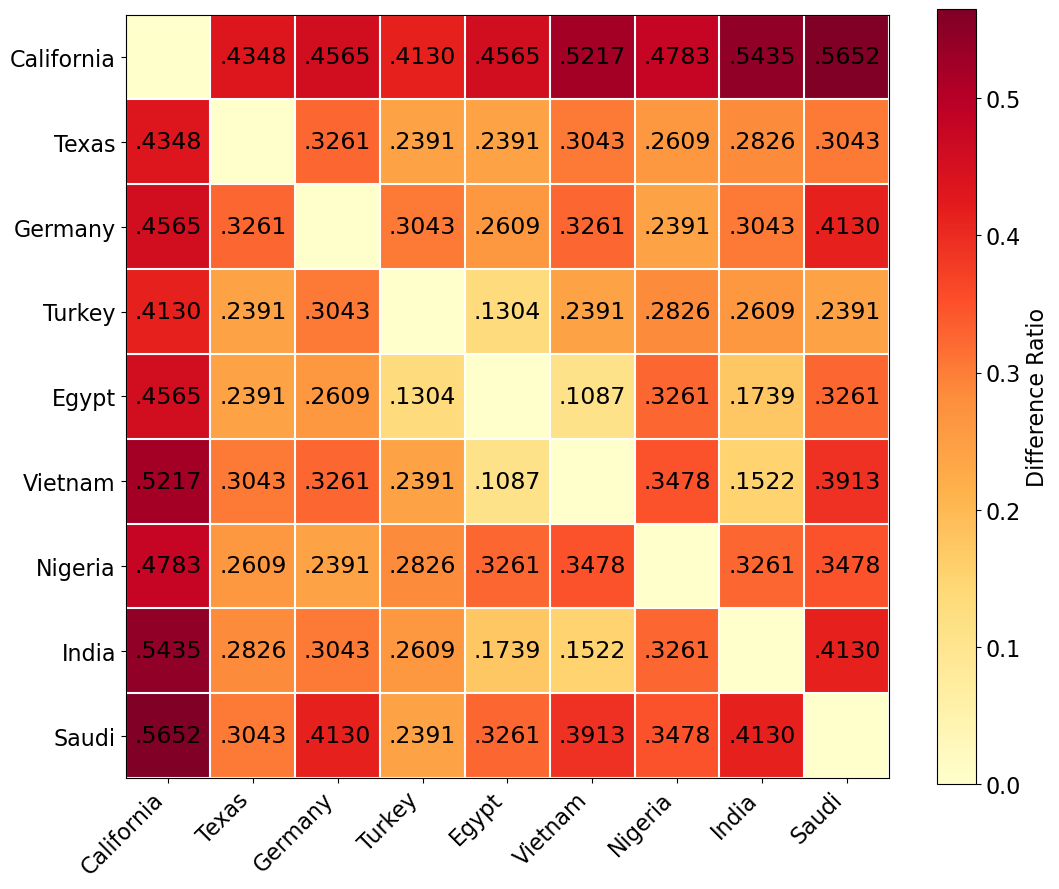

In [6]:
overall_matrix_save_path = output_path + "\\img" + "\\R_overall_matrix.pdf" 

plot_overall_diff_matrix(
    overall_matrix,
    # title="Overall Pairwise Regulation Difference",
    figsize=(11, 9),
    cmap= "YlOrRd", #"viridis", #"YlOrRd",
    annot=True,
    annot_fontsize=17,
    annot_color="black",
    tick_fontsize=16,
    title_fontsize=16,
    label_fontsize=16,
    colorbar_fontsize=16,
    rotation_x=45,
    save_path=overall_matrix_save_path
)